In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob, sys

In [23]:
idir = 'heatwave_detected'
point1, point2 = '47646', '47662'
d1  = pd.read_csv(idir + '/'+point1+'.csv', index_col=0, parse_dates=[1,2])
d2  = pd.read_csv(idir + '/'+point2+'.csv', index_col=0, parse_dates=[1,2])

In [29]:
d1

,Start,End,Duration
0,1960-08-01,1960-08-02,2
1,1961-07-08,1961-07-09,2
2,1961-08-17,1961-08-18,2
3,1964-08-12,1964-08-13,2
4,1964-08-15,1964-08-17,3
...,...,...,...
117,2023-07-24,2023-07-31,8
118,2023-08-02,2023-08-07,6
119,2023-08-16,2023-08-21,6
120,2023-08-24,2023-08-26,3


In [30]:
d2

,Start,End,Duration
0,1961-07-08,1961-07-09,2
1,1961-07-25,1961-07-28,4
2,1961-08-27,1961-08-28,2
3,1962-08-03,1962-08-04,2
4,1962-08-09,1962-08-10,2
...,...,...,...
119,2023-08-02,2023-08-08,7
120,2023-08-10,2023-08-12,3
121,2023-08-17,2023-08-21,5
122,2023-08-23,2023-08-25,3


In [45]:
import pandas as pd
from datetime import timedelta

# Example dataframes
# d1 = pd.read_csv("d1.csv")  # Tsukuba data
# d2 = pd.read_csv("d2.csv")  # Tokyo data

# Define time window in days
time_window = 3  # ±3 days

# Ensure date columns are datetime
d1['Start'] = pd.to_datetime(d1['Start'])
d1['End'] = pd.to_datetime(d1['End'])
d2['Start'] = pd.to_datetime(d2['Start'])
d2['End'] = pd.to_datetime(d2['End'])

# Find synchronized and non-synchronized events
synchronized_events = []
tsukuba_unsynced = d1.copy()
tokyo_unsynced = d2.copy()

# Collect indices to drop for non-synchronized events
tsukuba_to_drop = []
tokyo_to_drop = []

for idx1, row1 in d1.iterrows():
    synchronized = False
    for idx2, row2 in d2.iterrows():
        # Check overlap or relaxed synchronization within time_window
        if (row1['Start'] - timedelta(days=time_window) <= row2['End'] and
            row1['End'] + timedelta(days=time_window) >= row2['Start']):
            synchronized = True
            synchronized_events.append({
                'Tsukuba_Start': row1['Start'],
                'Tsukuba_End': row1['End'],
                'Tokyo_Start': row2['Start'],
                'Tokyo_End': row2['End']
            })
            tokyo_to_drop.append(idx2)  # Mark Tokyo event for removal
    # Mark Tsukuba event for removal if synchronized
    if synchronized:
        tsukuba_to_drop.append(idx1)

# Drop synchronized events from the non-synchronized dataframes
tsukuba_unsynced = tsukuba_unsynced.drop(tsukuba_to_drop)
tokyo_unsynced = tokyo_unsynced.drop(tokyo_to_drop)

# Convert synchronized events to dataframe
synchronized_df = pd.DataFrame(synchronized_events)


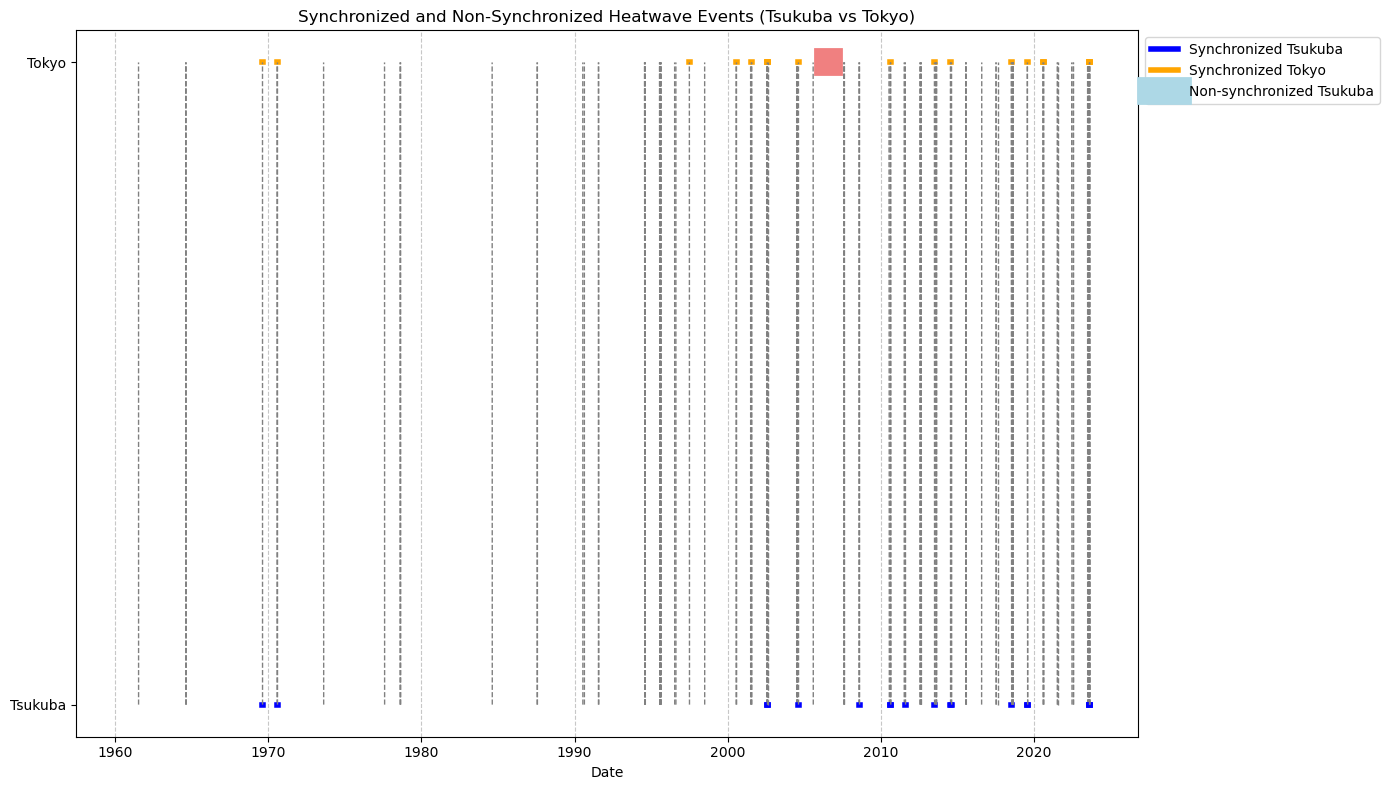

In [48]:
# Convert date strings to datetime
synchronized_df[['Tsukuba_Start', 'Tsukuba_End', 'Tokyo_Start', 'Tokyo_End']] = synchronized_df[
    ['Tsukuba_Start', 'Tsukuba_End', 'Tokyo_Start', 'Tokyo_End']
].apply(pd.to_datetime)

tsukuba_unsynced[['Start', 'End']] = tsukuba_unsynced[['Start', 'End']].apply(pd.to_datetime)
tokyo_unsynced[['Start', 'End']] = tokyo_unsynced[['Start', 'End']].apply(pd.to_datetime)

# Set up the plot
plt.figure(figsize=(14, 8))

# Plot synchronized events
for idx, row in synchronized_df.iterrows():
    # Plot Tsukuba synchronized event
    plt.plot([row['Tsukuba_Start'], row['Tsukuba_End']], [1, 1], color='blue', linewidth=4, label="Synchronized Tsukuba" if idx == 0 else "")
    # Plot Tokyo synchronized event
    plt.plot([row['Tokyo_Start'], row['Tokyo_End']], [2, 2], color='orange', linewidth=4, label="Synchronized Tokyo" if idx == 0 else "")
    # Draw line connecting synchronized events
    plt.plot([row['Tsukuba_End'], row['Tokyo_Start']], [1, 2], color='gray', linestyle='--', linewidth=1)

# Plot non-synchronized Tsukuba events
for idx, row in tsukuba_unsynced.iterrows():
    plt.plot([row['Start'], row['End']], [1, 1], color='lightblue', linewidth=20, label="Non-synchronized Tsukuba" if idx == 0 else "")

# Plot non-synchronized Tokyo events
for idx, row in tokyo_unsynced.iterrows():
    plt.plot([row['Start'], row['End']], [2, 2], color='lightcoral', linewidth=20, label="Non-synchronized Tokyo" if idx == 0 else "")

# Customize the plot
plt.yticks([1, 2], ['Tsukuba', 'Tokyo'])
plt.xlabel('Date')
plt.title('Synchronized and Non-Synchronized Heatwave Events (Tsukuba vs Tokyo)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

In [49]:
# Number of synchronized events
num_synchronized = len(synchronized_df)

# Total number of events in Tsukuba and Tokyo
total_events = len(d1) + len(d2)

# Synchronized rate
synchronized_rate = num_synchronized / total_events

# Display the result
print(f"Number of synchronized events: {num_synchronized}")
print(f"Total number of events (Tsukuba + Tokyo): {total_events}")
print(f"Synchronized rate: {synchronized_rate:.2%}")


Number of synchronized events: 131
Total number of events (Tsukuba + Tokyo): 246
Synchronized rate: 53.25%


In [50]:
# Total number of events in Tsukuba and Tokyo
total_events_tsukuba = len(d1)
total_events_tokyo = len(d2)

# Number of synchronized events at each place
num_synchronized_tsukuba = synchronized_df['Tsukuba_Start'].nunique()
num_synchronized_tokyo = synchronized_df['Tokyo_Start'].nunique()

# Synchronized rates
synchronized_rate_tsukuba = num_synchronized_tsukuba / total_events_tsukuba
synchronized_rate_tokyo = num_synchronized_tokyo / total_events_tokyo

# Display the results
print(f"Number of synchronized events in Tsukuba: {num_synchronized_tsukuba}")
print(f"Total number of events in Tsukuba: {total_events_tsukuba}")
print(f"Synchronized rate in Tsukuba: {synchronized_rate_tsukuba:.2%}")

print(f"Number of synchronized events in Tokyo: {num_synchronized_tokyo}")
print(f"Total number of events in Tokyo: {total_events_tokyo}")
print(f"Synchronized rate in Tokyo: {synchronized_rate_tokyo:.2%}")


Number of synchronized events in Tsukuba: 98
Total number of events in Tsukuba: 122
Synchronized rate in Tsukuba: 80.33%
Number of synchronized events in Tokyo: 95
Total number of events in Tokyo: 124
Synchronized rate in Tokyo: 76.61%
